# Training Curve Visualization

Reads the `outputs/metrics_<run_name>.json` files written by `train.py` every epoch and plots learning curves. Re-run cells anytime during or after training — the JSON updates live each epoch, so plots reflect current progress if training is still running.

Run names follow the pattern: `baseline`, `cnn_lstm`, `cnn_lstm_shuffled` (the three required experiments).

In [3]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUTS_DIR = Path("outputs")

def load_history(run_name):
    path = OUTPUTS_DIR / f"metrics_{run_name}.json"
    if not path.exists():
        print(f"No metrics file found for '{run_name}' at {path}")
        return None
    with open(path) as f:
        data = json.load(f)
    return data["history"]

# Edit this list to match whichever runs you've actually started
RUN_NAMES = ["baseline_aug", "cnn_lstm_aug", "cnn_lstm_shuffled_aug"]

histories = {}
for name in RUN_NAMES:
    h = load_history(name)
    if h:
        histories[name] = h
        print(f"{name}: {len(h)} epochs logged")

baseline_aug: 90 epochs logged
cnn_lstm_aug: 90 epochs logged
cnn_lstm_shuffled_aug: 90 epochs logged


In [6]:
from glob import glob

def load_history(run_name):
    path = OUTPUTS_DIR / f"metrics_{run_name}.json"
    if not path.exists():
        print(f"No metrics file found for '{run_name}' at {path}")
        return None
    with open(path) as f:
        data = json.load(f)
    return data["history"]

# Auto-discover all metrics files instead of hardcoding names
metrics_files = sorted(glob(str(OUTPUTS_DIR / "metrics_*.json")))
RUN_NAMES = [Path(f).stem.replace("metrics_", "", 1) for f in metrics_files]
print(f"Found {len(RUN_NAMES)} runs: {RUN_NAMES}")

histories = {}
for name in RUN_NAMES:
    h = load_history(name)
    if h:
        histories[name] = h
        print(f"{name}: {len(h)} epochs logged")

Found 35 runs: ['baseline', 'baseline:best', 'baseline_aug', 'baseline_aug_ce_wd0.01_es20', 'baseline_aug_core', 'baseline_core', 'cnn_lstm', 'cnn_lstm:best', 'cnn_lstm_aug', 'cnn_lstm_aug_ce_wd0.01', 'cnn_lstm_aug_ce_wd0.01_es20', 'cnn_lstm_aug_core', 'cnn_lstm_aug_wd0.01_es10', 'cnn_lstm_core', 'cnn_lstm_shuffled', 'cnn_lstm_shuffled:best', 'cnn_lstm_shuffled_aug', 'cnn_lstm_shuffled_aug_core', 'cnn_lstm_shuffled_core', 'convgru_aug_ce_wd0.01_es20_nonelr', 'convgru_aug_ce_wd0.01_es20_nonelr_seed1234', 'convgru_aug_ce_wd0.01_es20_nonelr_seed7', 'convlstm', 'convlstm_aug_ce_wd0.01', 'convlstm_aug_ce_wd0.01_es20', 'convlstm_aug_ce_wd0.01_es20_nonelr', 'convlstm_aug_ce_wd0.01_es20_nonelr_seed1234', 'convlstm_aug_ce_wd0.01_es20_nonelr_seed7', 'convlstm_aug_ce_wd0.01_es30', 'convlstm_aug_core_ce_wd0.01_es20_nonelr', 'convlstm_aug_wd0.01', 'convlstm_aug_wd0.01_es10', 'convlstm_shuffled_aug_ce_wd0.01_es20_nonelr', 'convlstm_shuffled_aug_ce_wd0.01_es20_nonelr_seed1234', 'convlstm_shuffled_aug

## Single-run plot: loss + F1 + AUROC over epochs

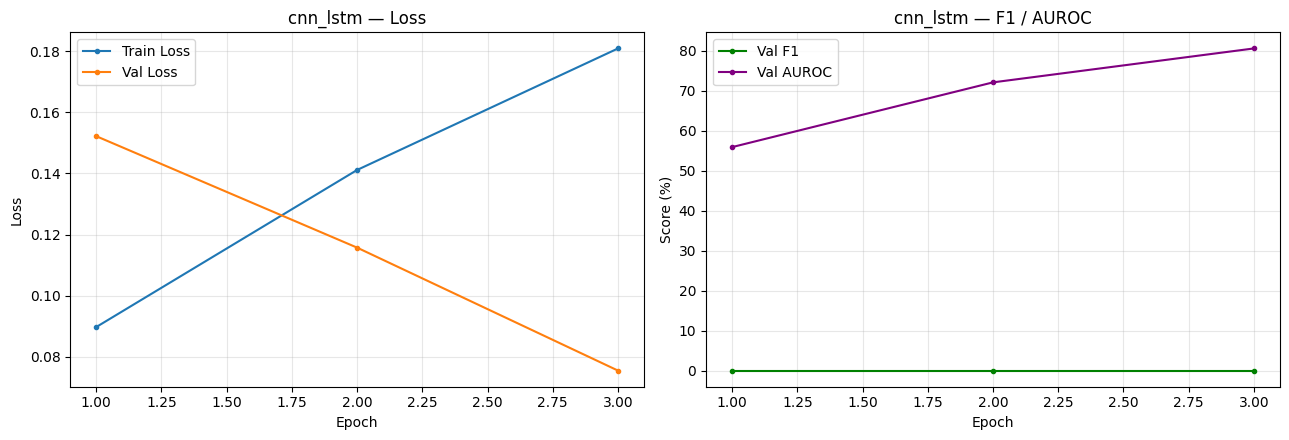

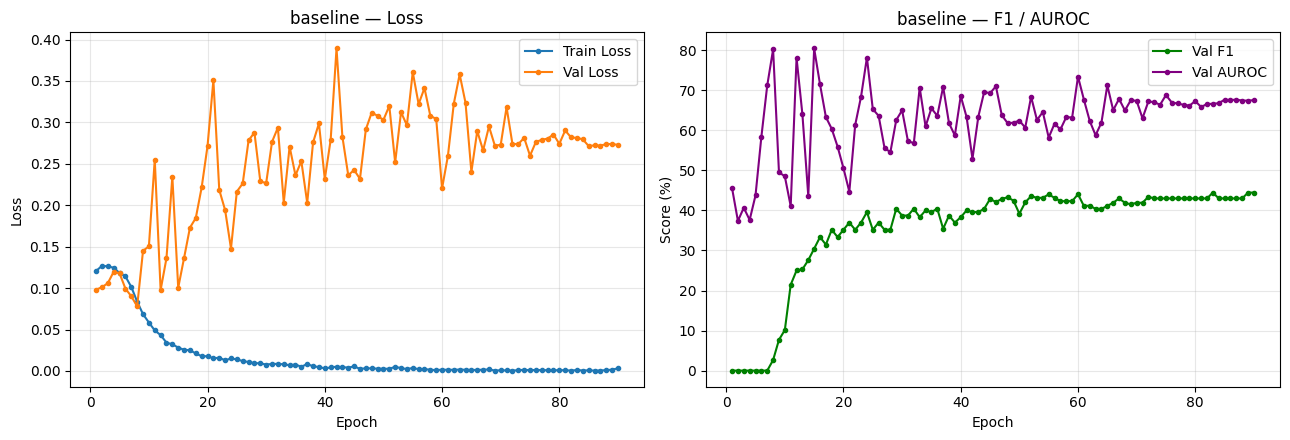

In [7]:
def plot_single_run(run_name):
    h = histories.get(run_name)
    if not h:
        print(f"No data for {run_name}")
        return

    epochs = [e["epoch"] for e in h]
    train_loss = [e["train_loss"] for e in h]
    val_loss = [e["val_loss"] for e in h]
    val_f1 = [e["val_f1"] for e in h]
    val_auroc = [e["val_auroc"] for e in h]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, train_loss, label="Train Loss", marker='o', markersize=3)
    axes[0].plot(epochs, val_loss, label="Val Loss", marker='o', markersize=3)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{run_name} — Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, val_f1, label="Val F1", marker='o', markersize=3, color='green')
    axes[1].plot(epochs, val_auroc, label="Val AUROC", marker='o', markersize=3, color='purple')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score (%)")
    axes[1].set_title(f"{run_name} — F1 / AUROC")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Change this to whichever run you want to inspect
plot_single_run("cnn_lstm")
plot_single_run("baseline")

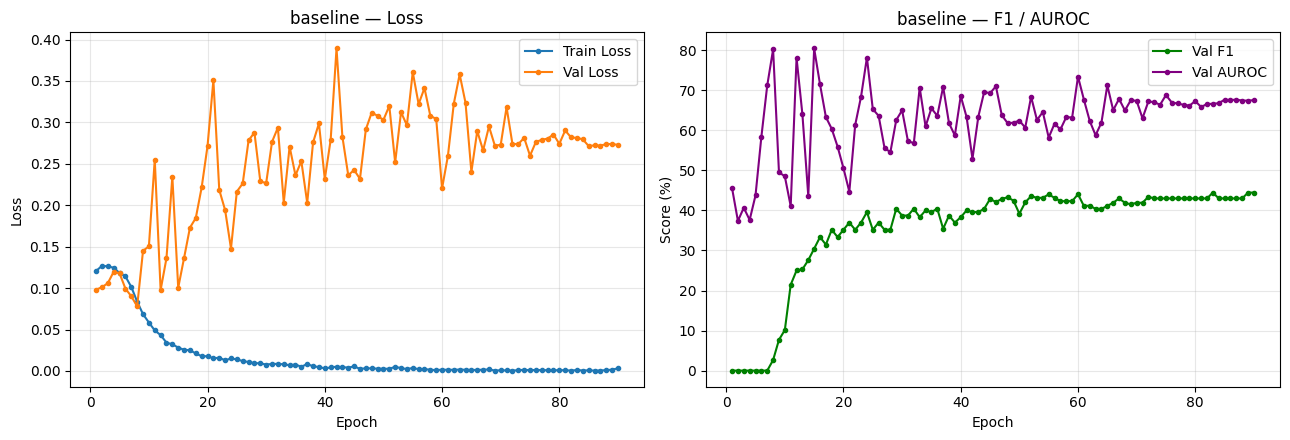

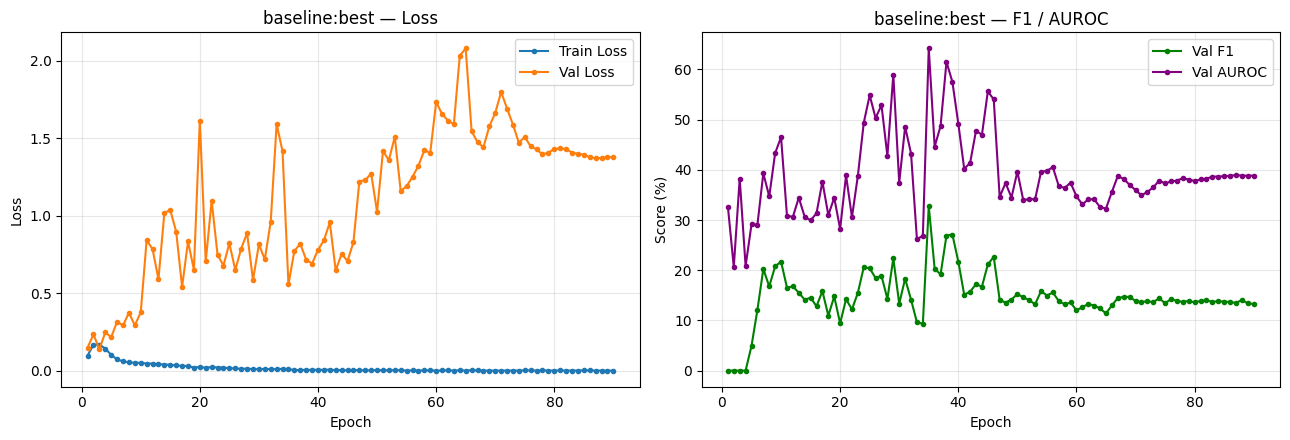

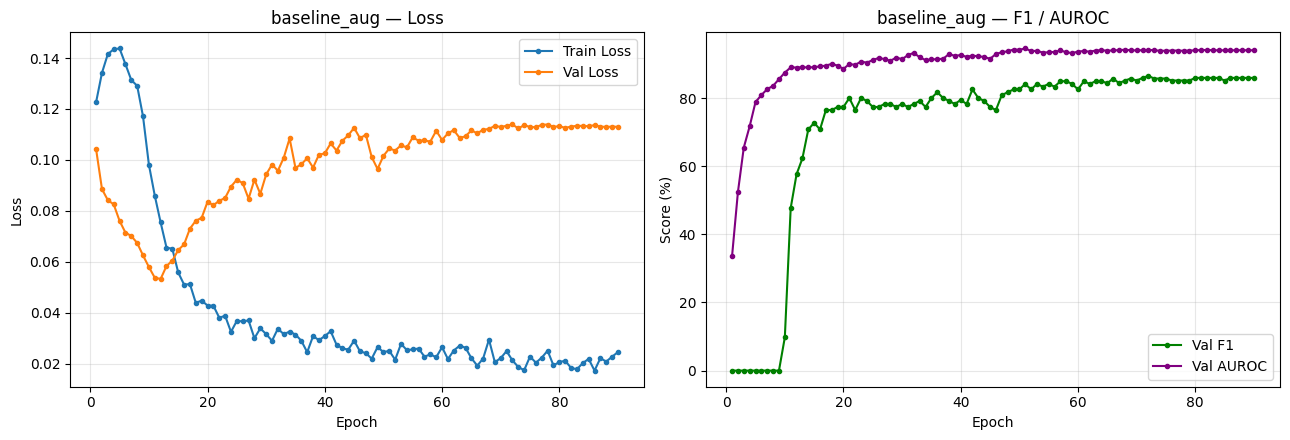

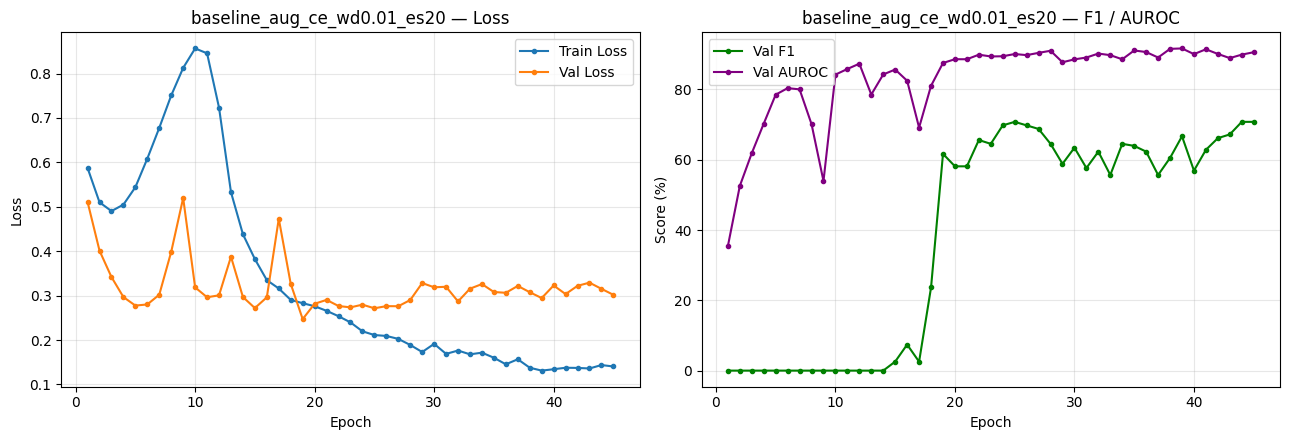

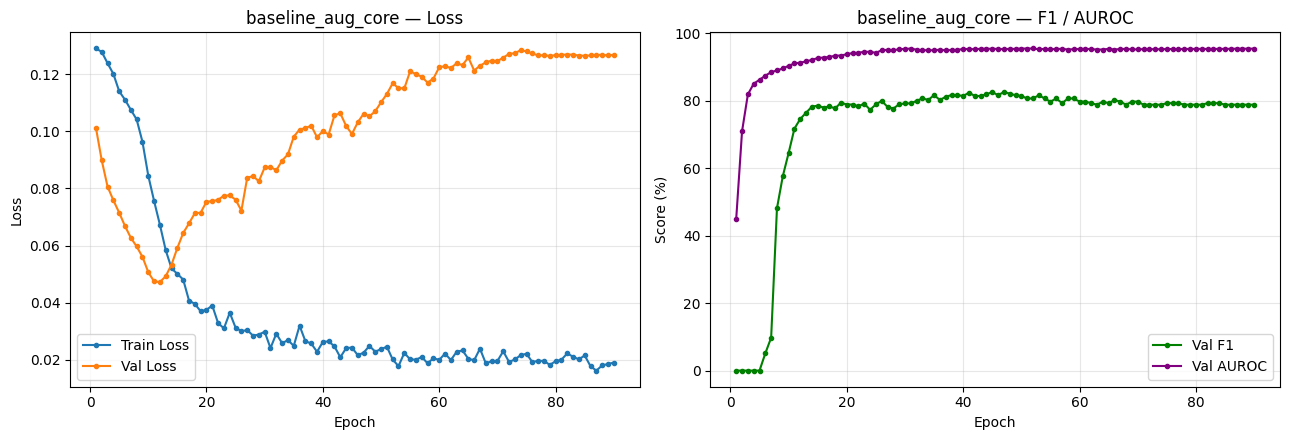

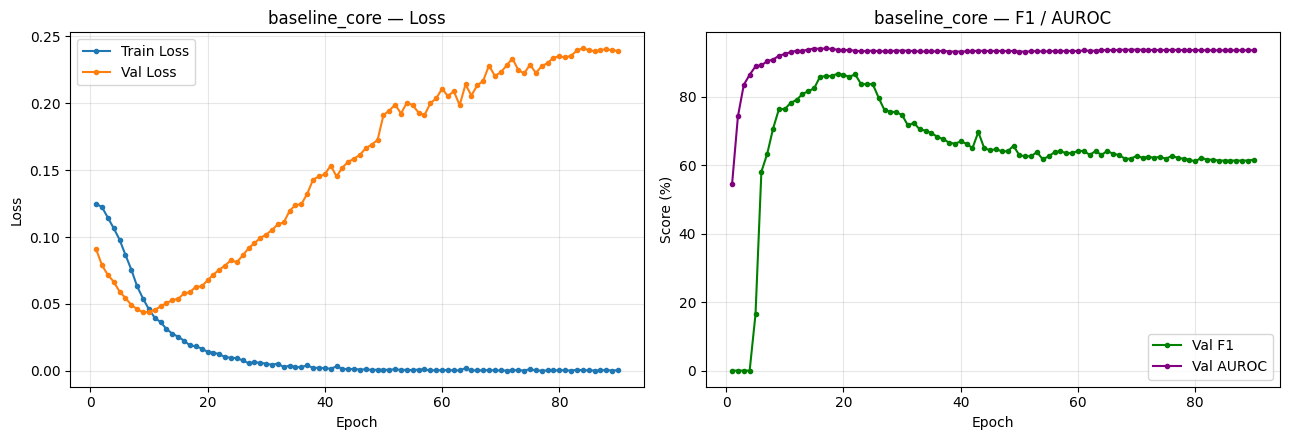

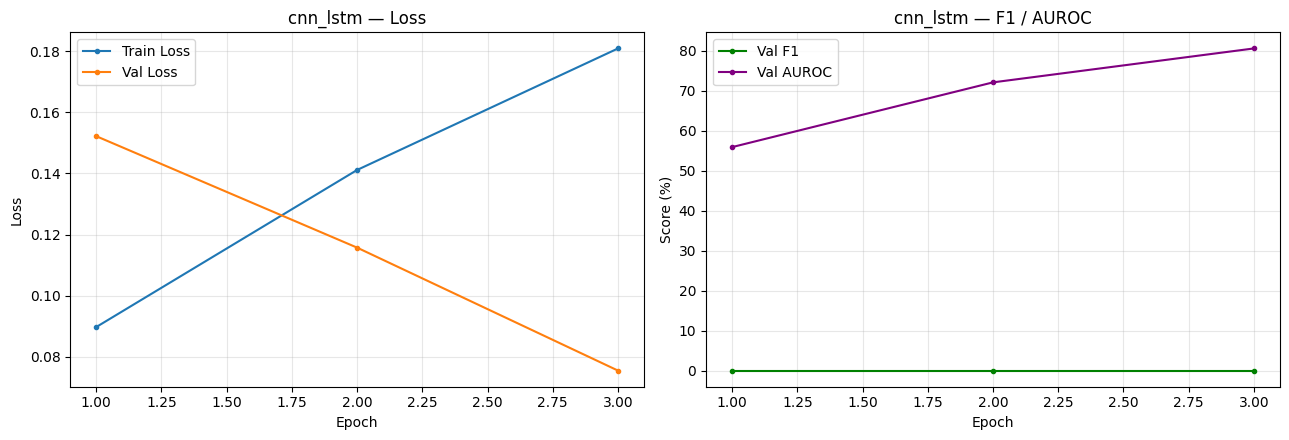

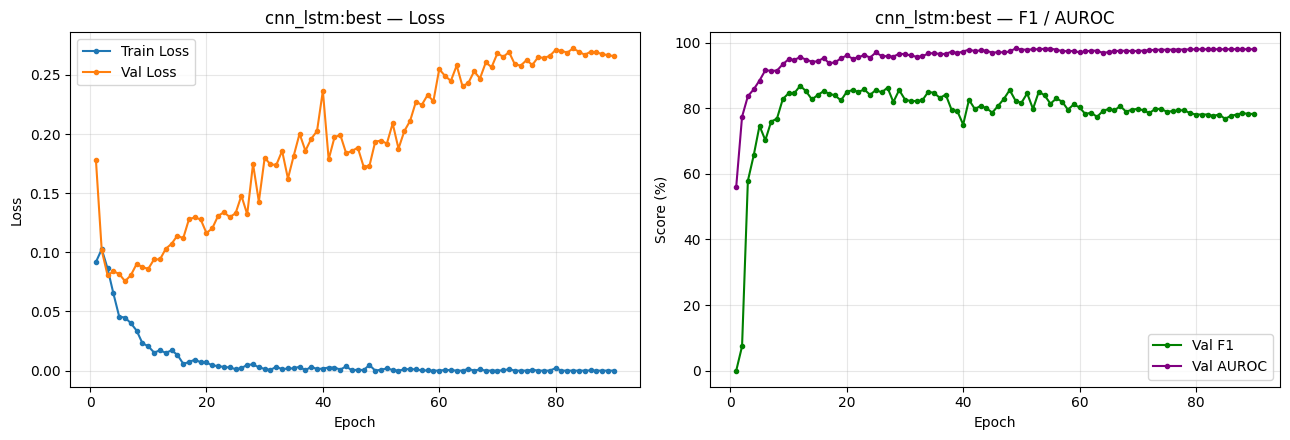

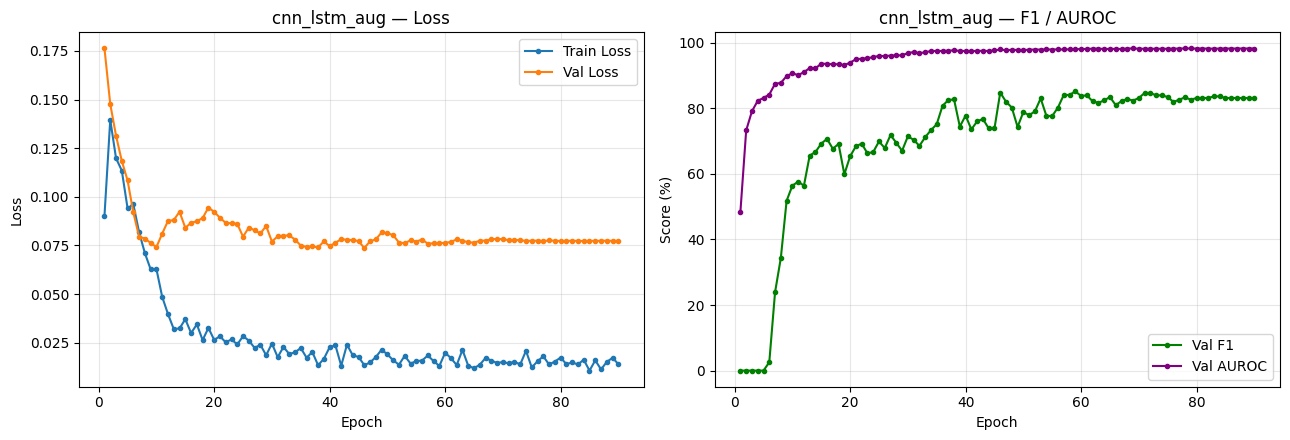

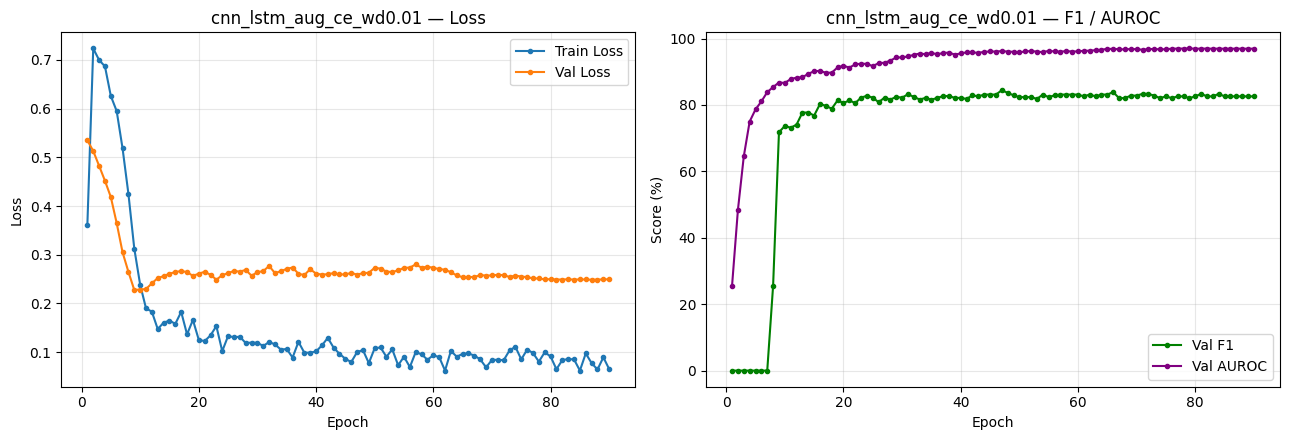

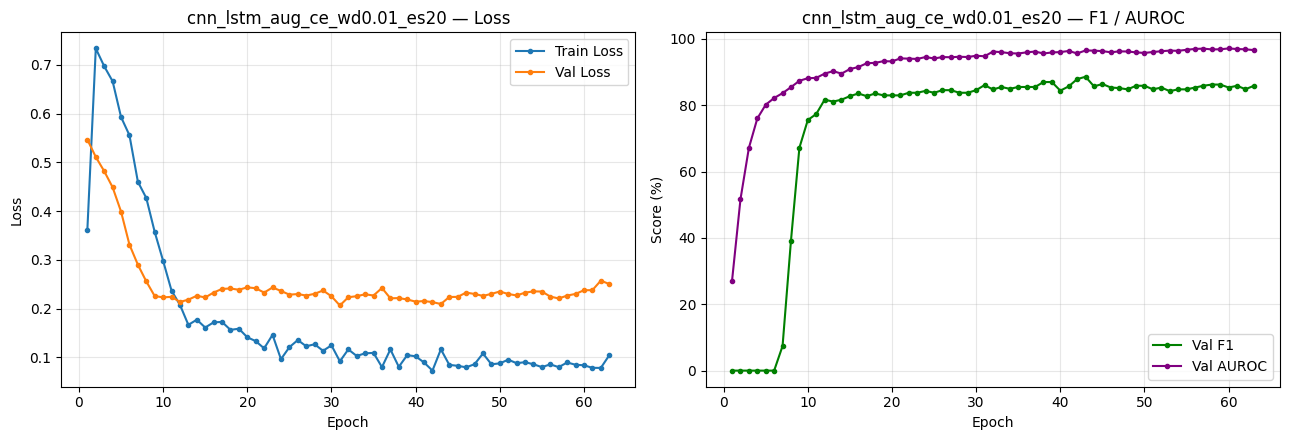

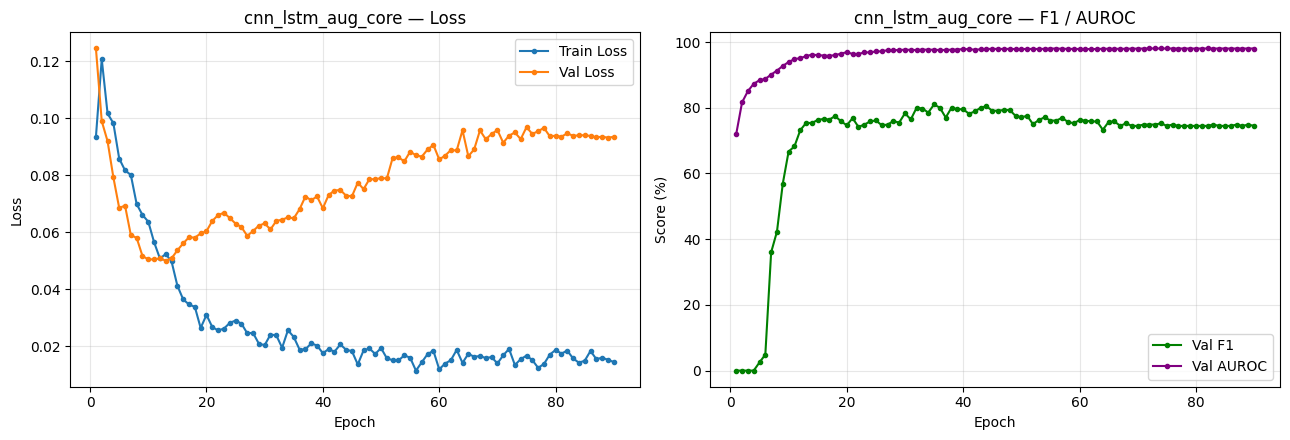

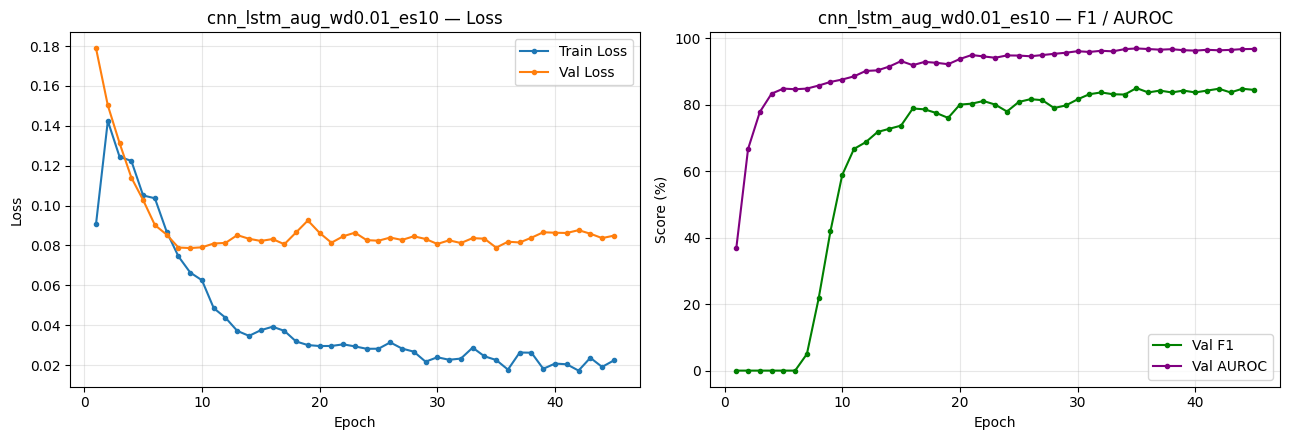

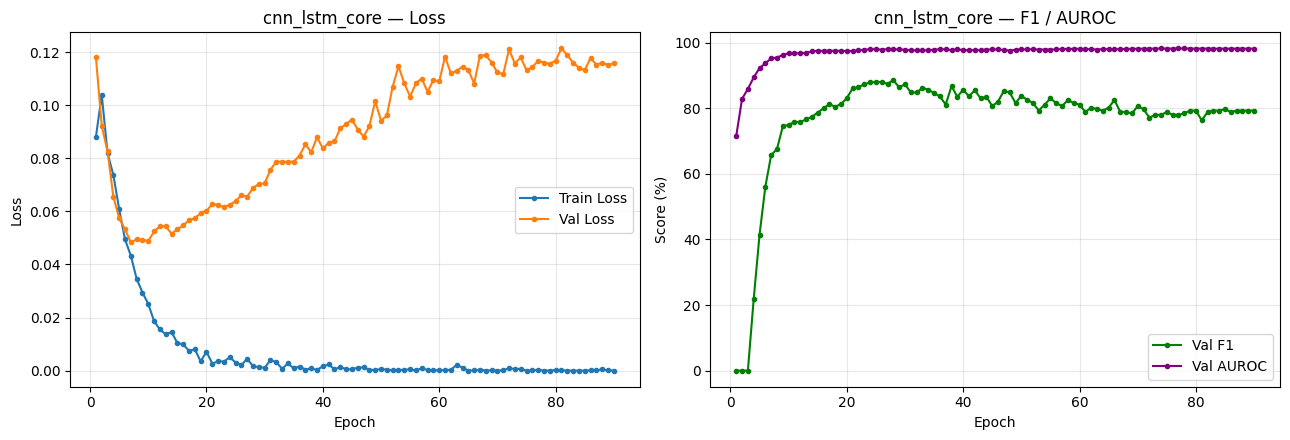

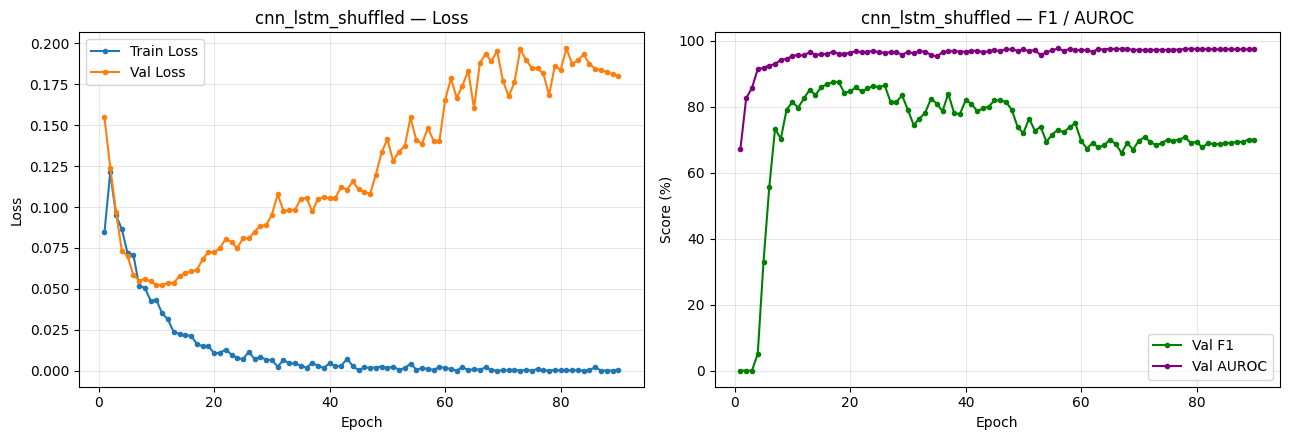

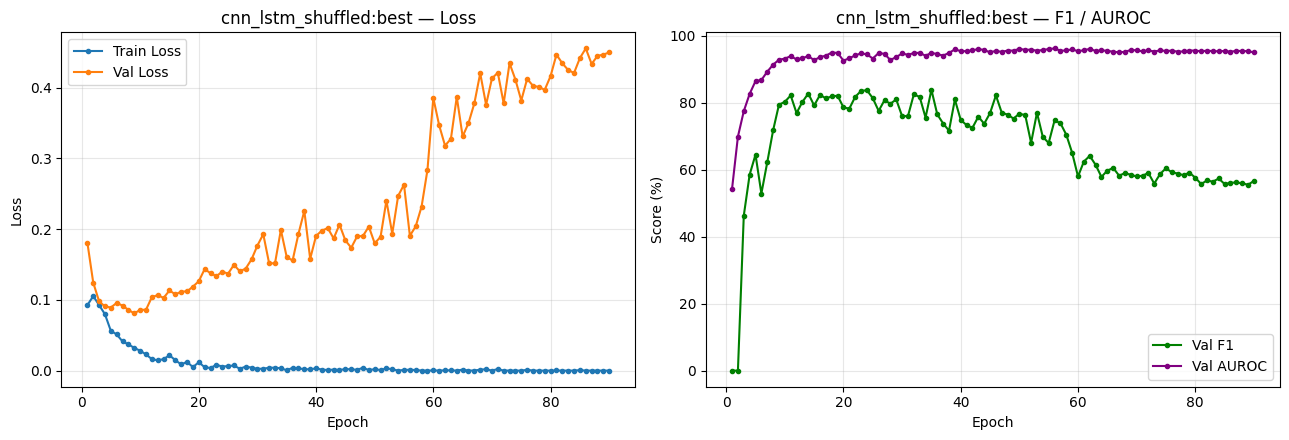

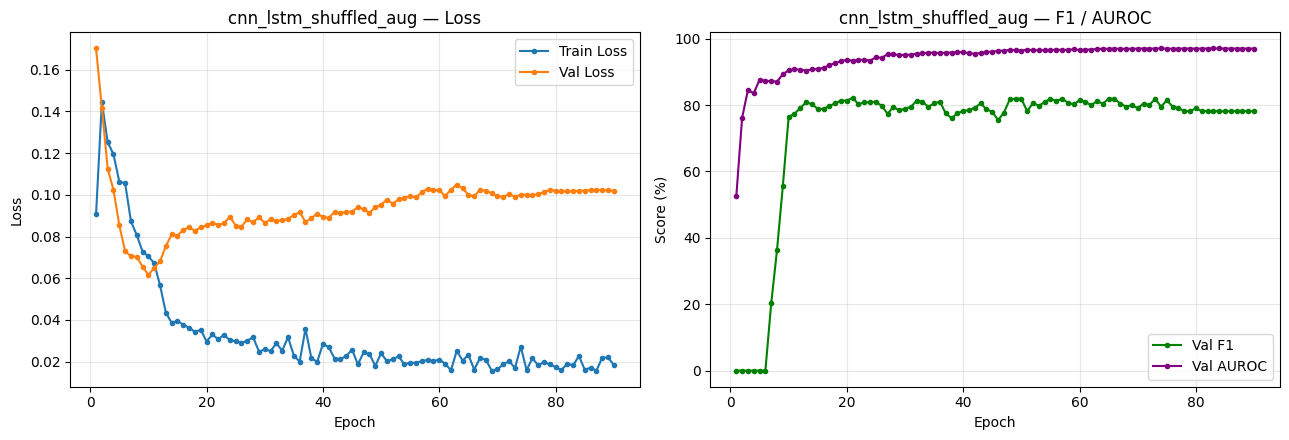

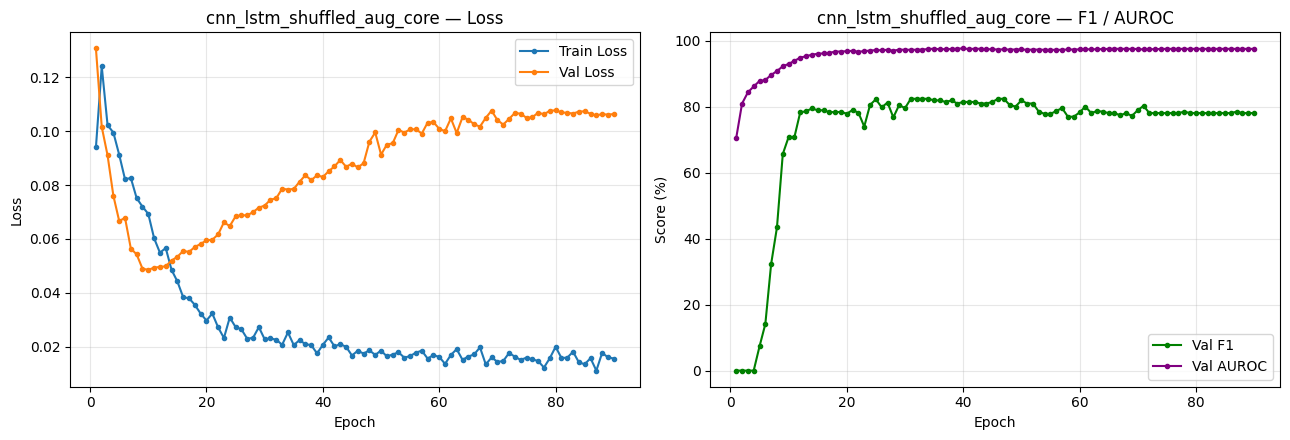

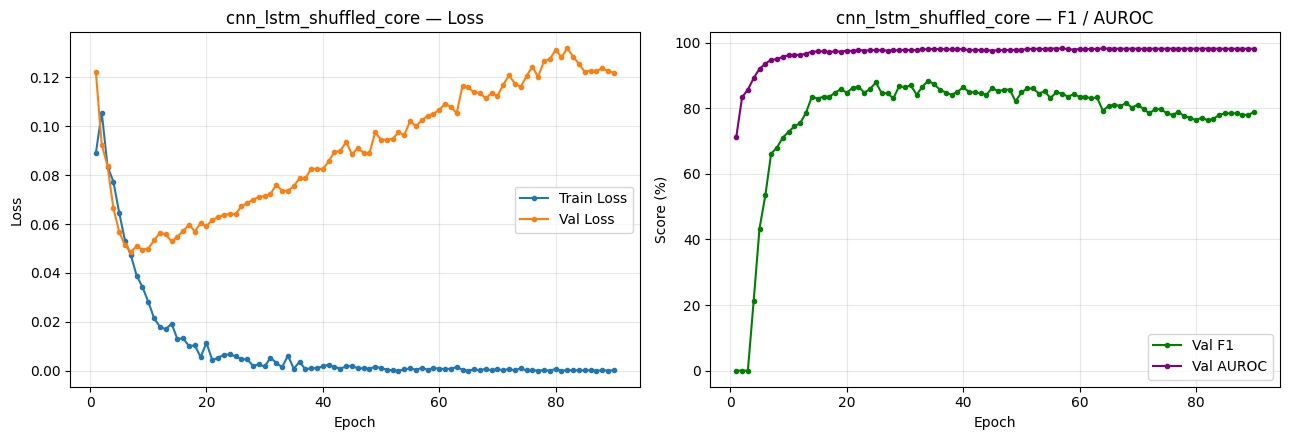

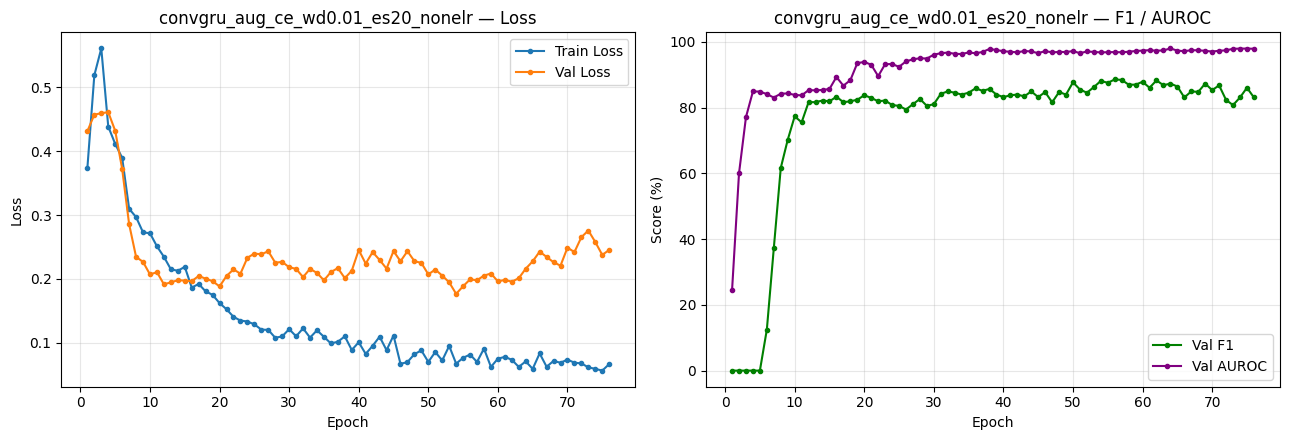

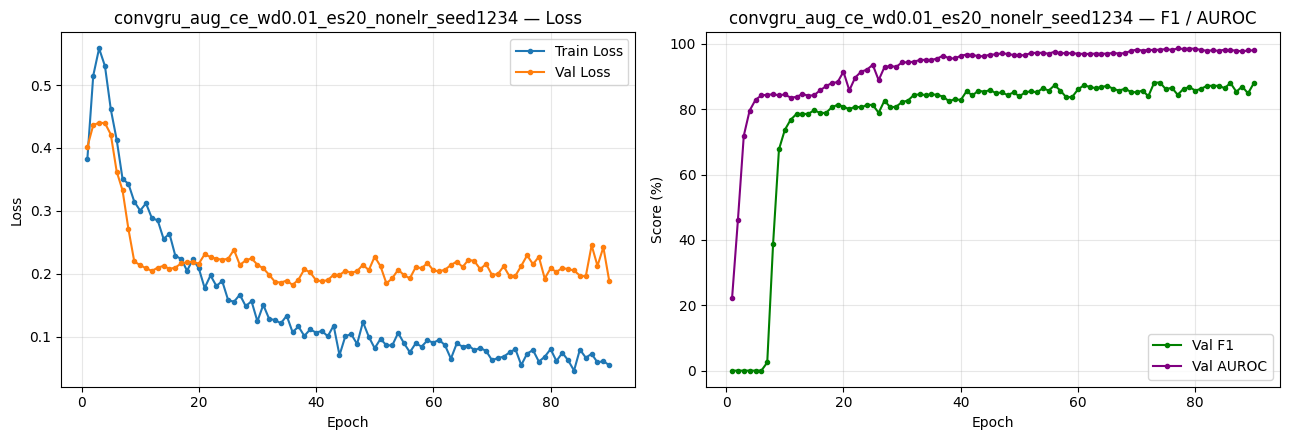

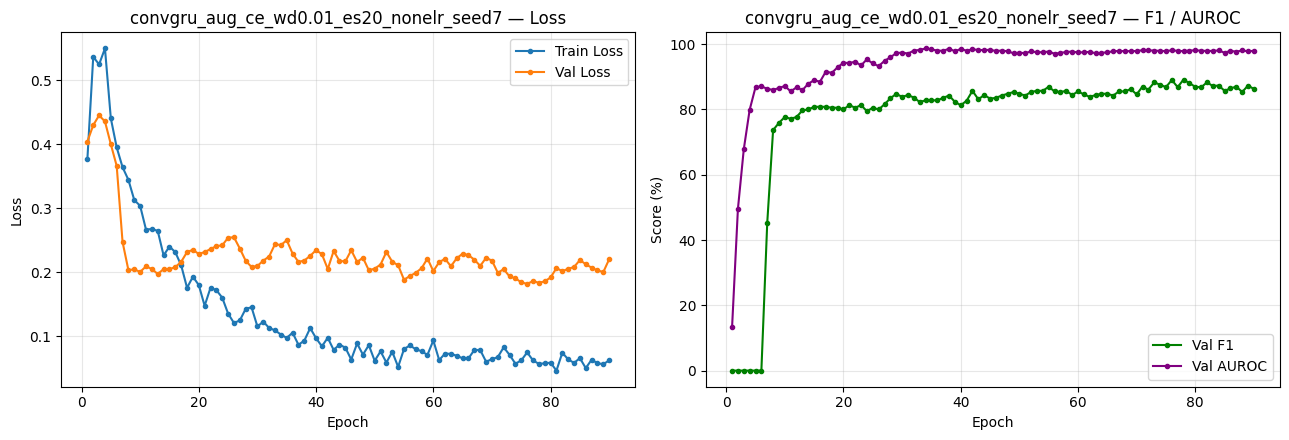

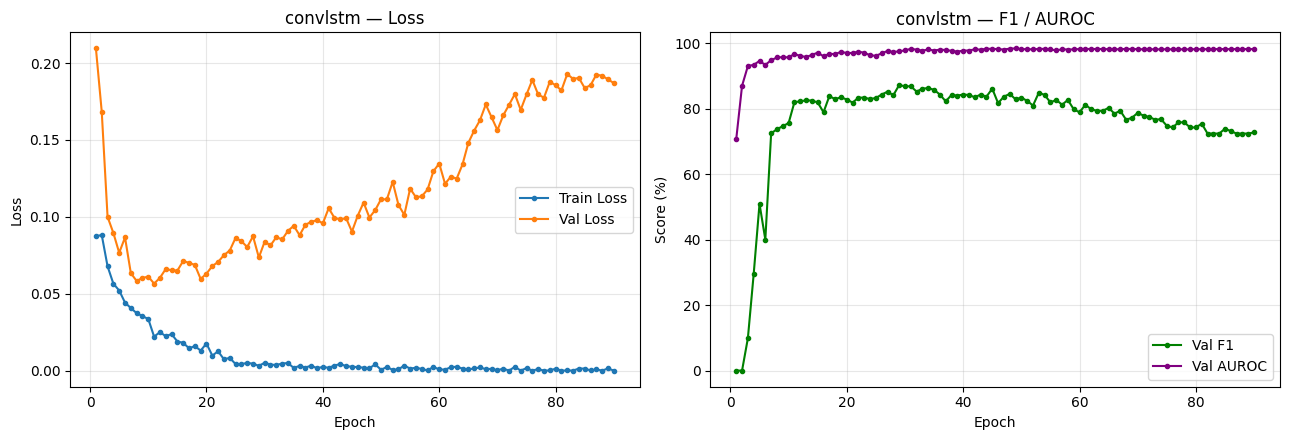

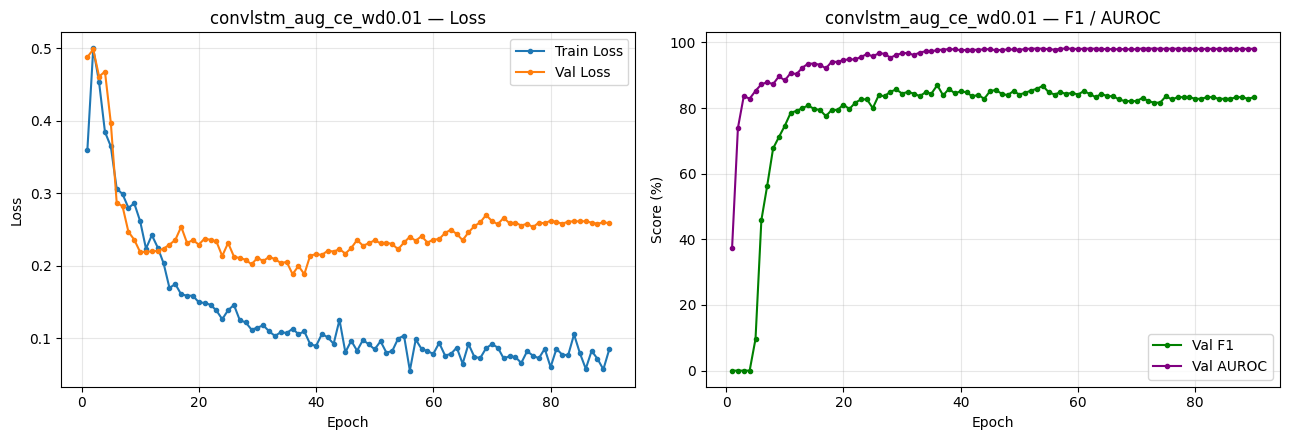

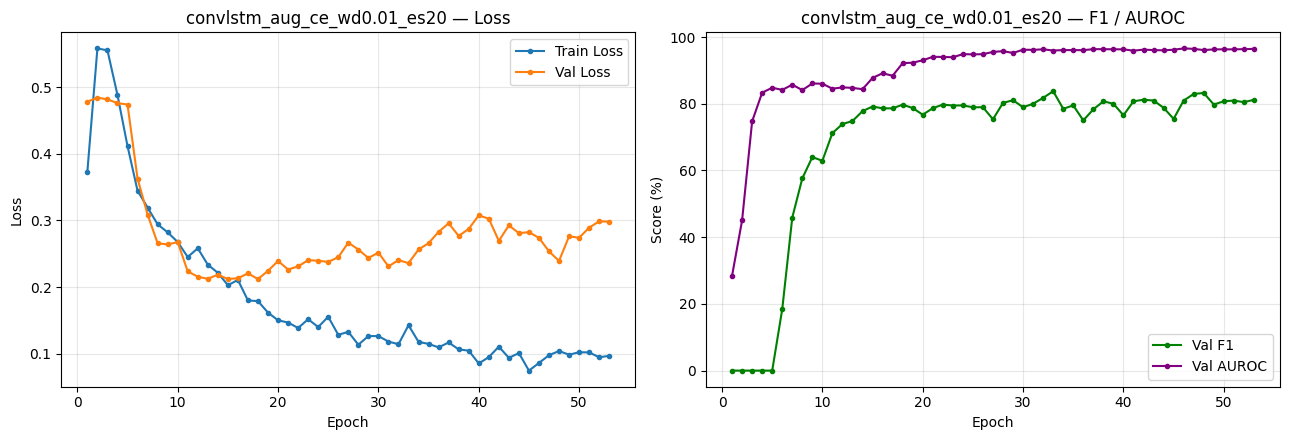

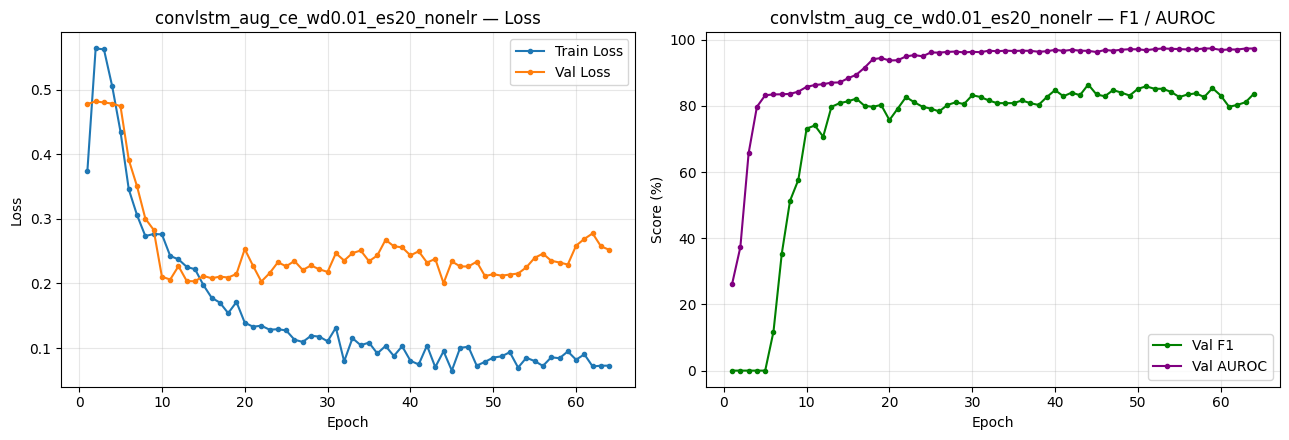

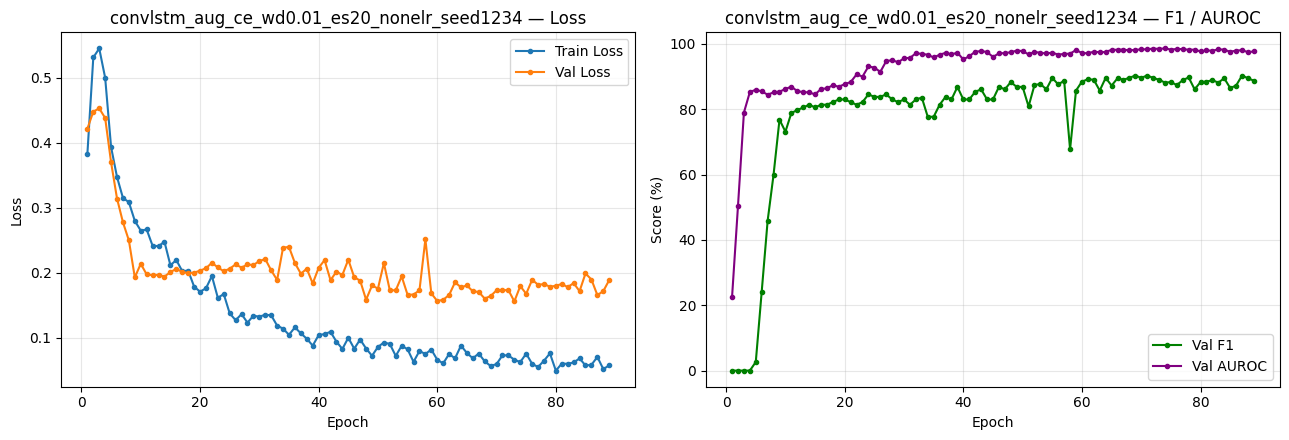

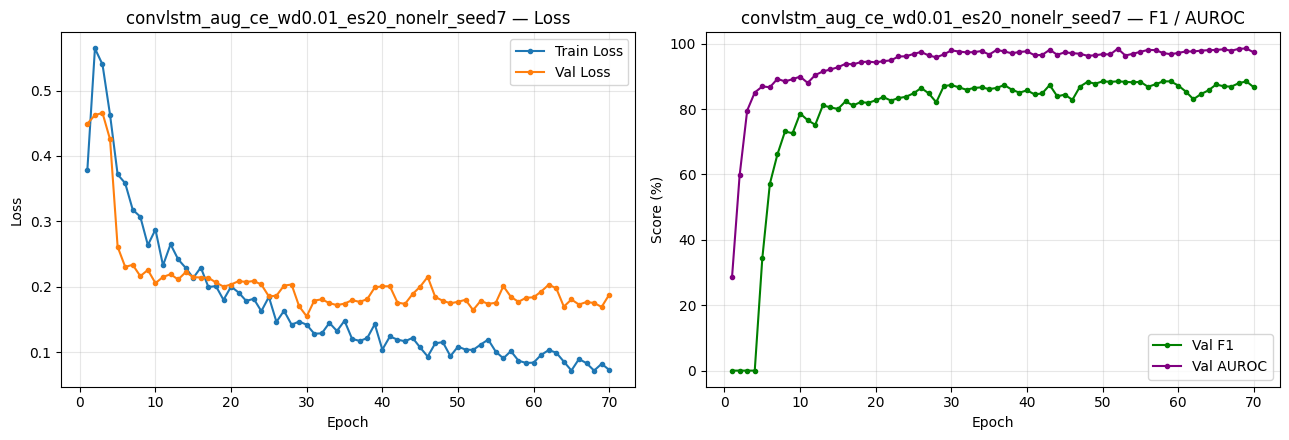

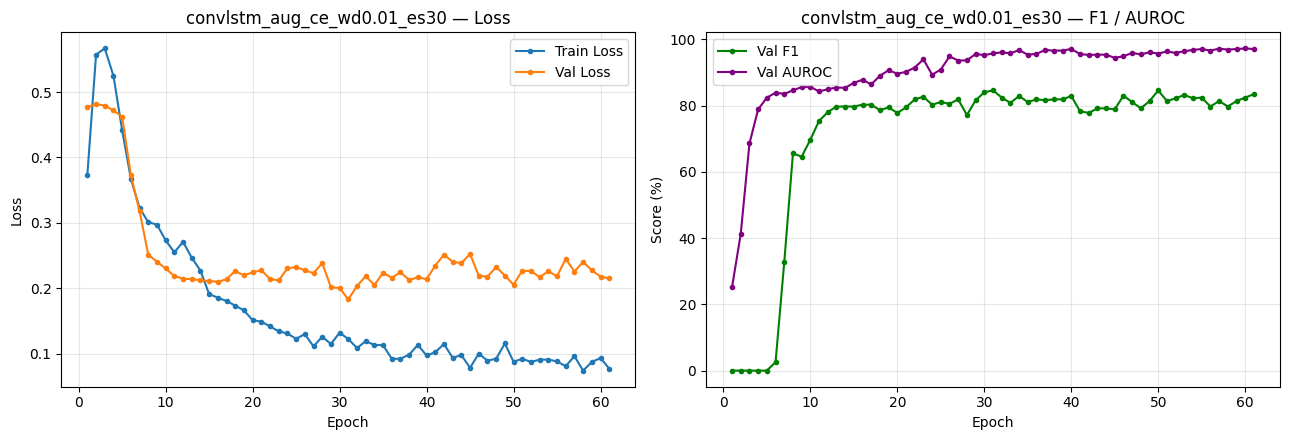

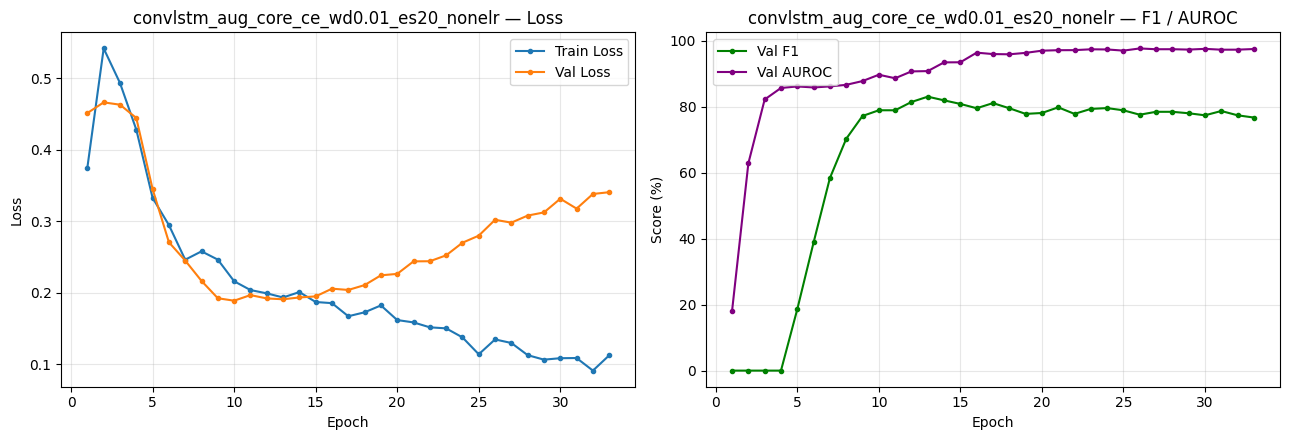

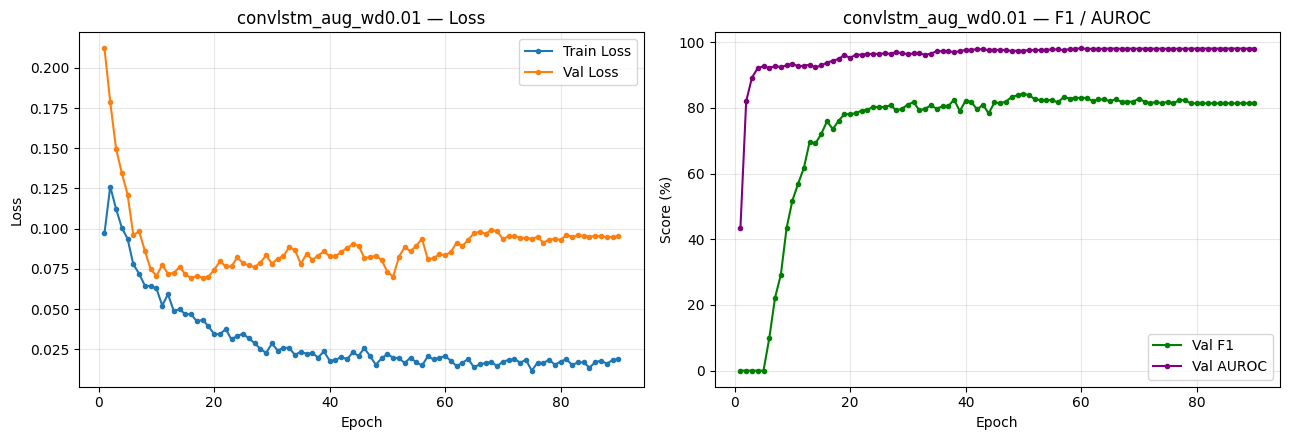

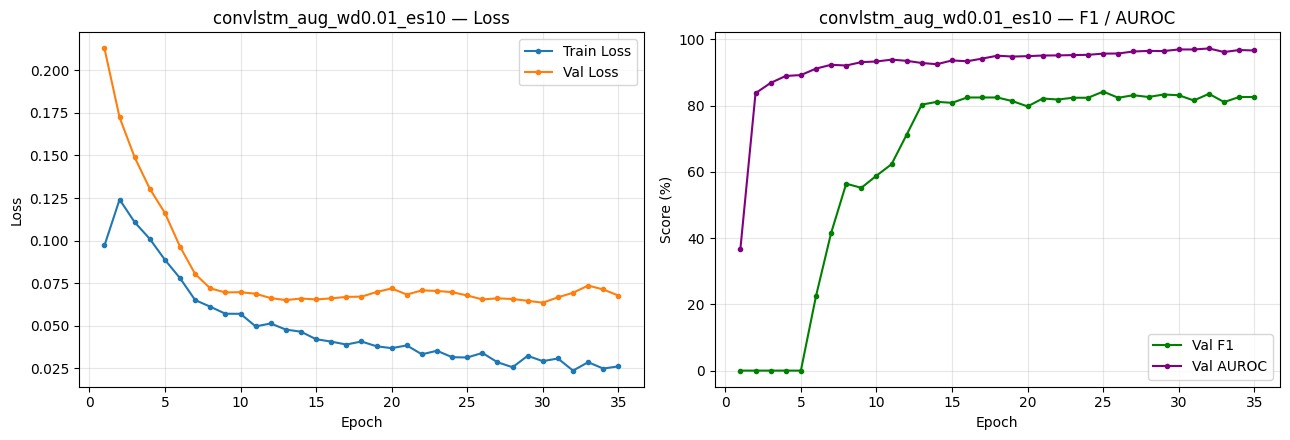

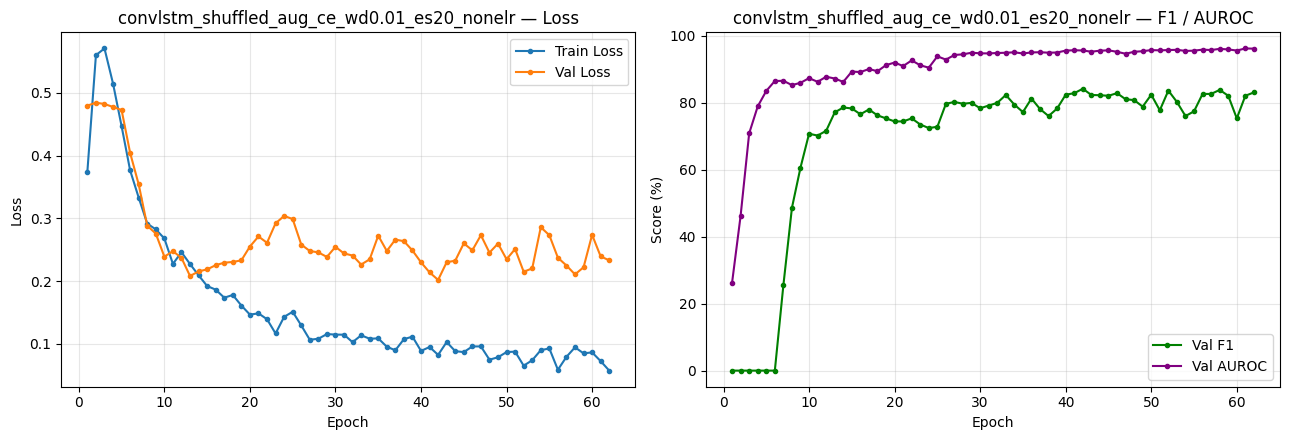

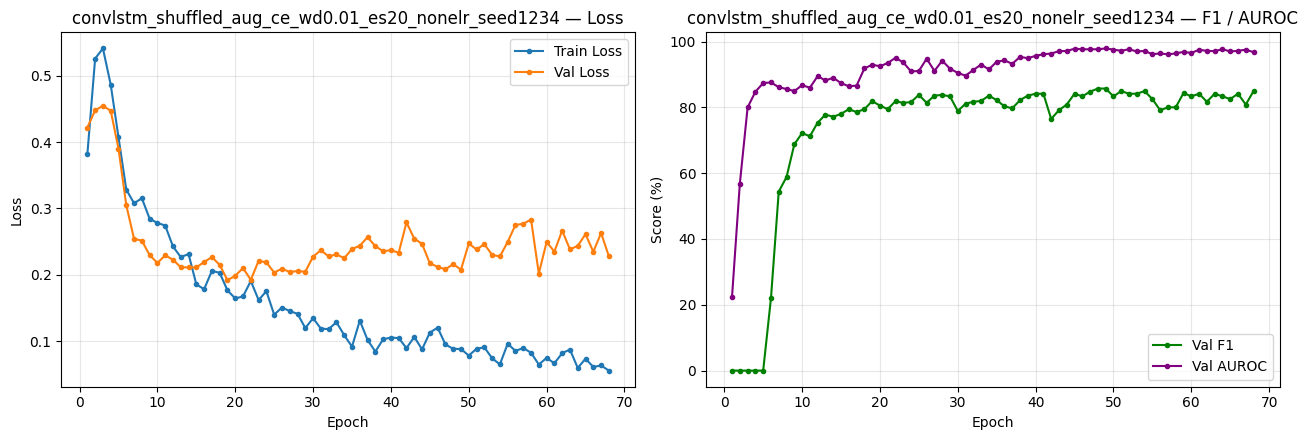

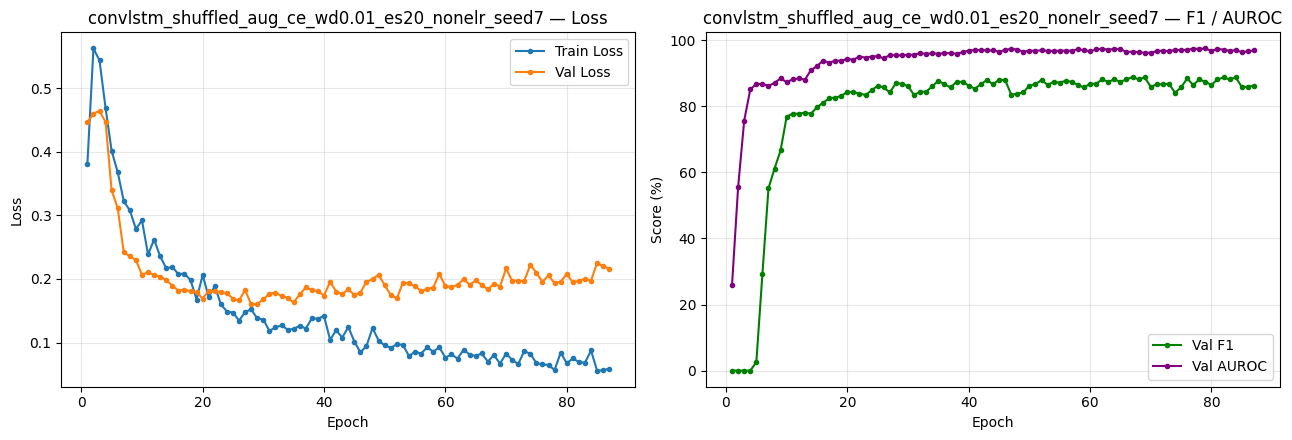

In [8]:
#new code to plot all runs
def plot_single_run(run_name):
    h = histories.get(run_name)
    if not h:
        print(f"No data for {run_name}")
        return

    epochs = [e["epoch"] for e in h]
    train_loss = [e["train_loss"] for e in h]
    val_loss = [e["val_loss"] for e in h]
    val_f1 = [e["val_f1"] for e in h]
    val_auroc = [e["val_auroc"] for e in h]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, train_loss, label="Train Loss", marker='o', markersize=3)
    axes[0].plot(epochs, val_loss, label="Val Loss", marker='o', markersize=3)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{run_name} — Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, val_f1, label="Val F1", marker='o', markersize=3, color='green')
    axes[1].plot(epochs, val_auroc, label="Val AUROC", marker='o', markersize=3, color='purple')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score (%)")
    axes[1].set_title(f"{run_name} — F1 / AUROC")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot every run that got loaded into histories
for run_name in histories:
    plot_single_run(run_name)

## Comparison plot: all runs together (the actual thesis result)

This is the plot that matters for your shuffle ablation argument: if `cnn_lstm` clearly beats `cnn_lstm_shuffled` on F1, that's your evidence that frame ordering carries real signal.

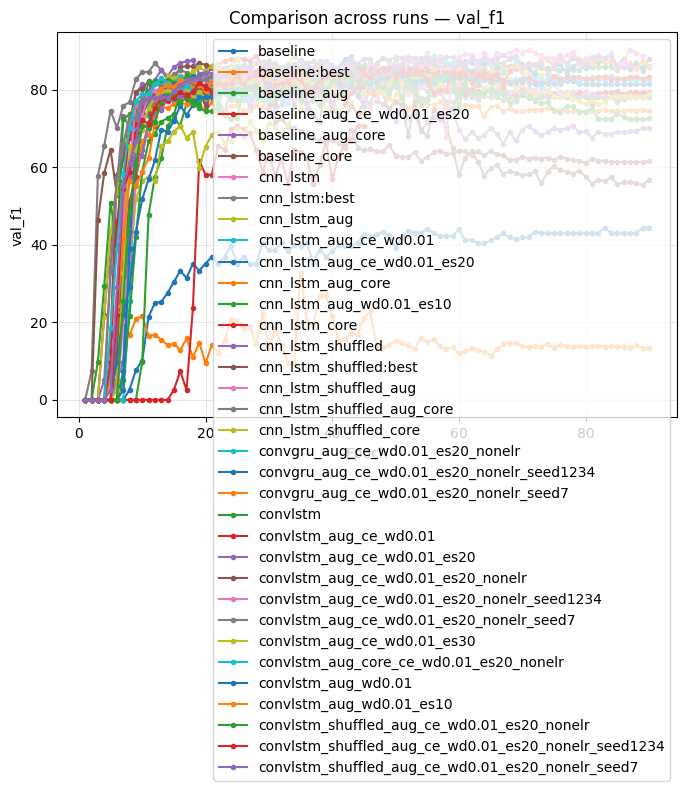

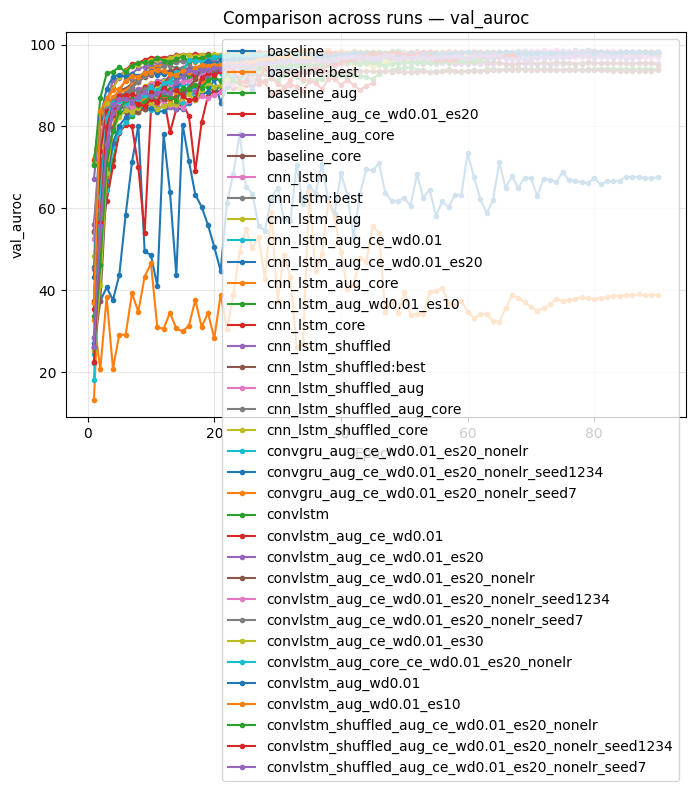

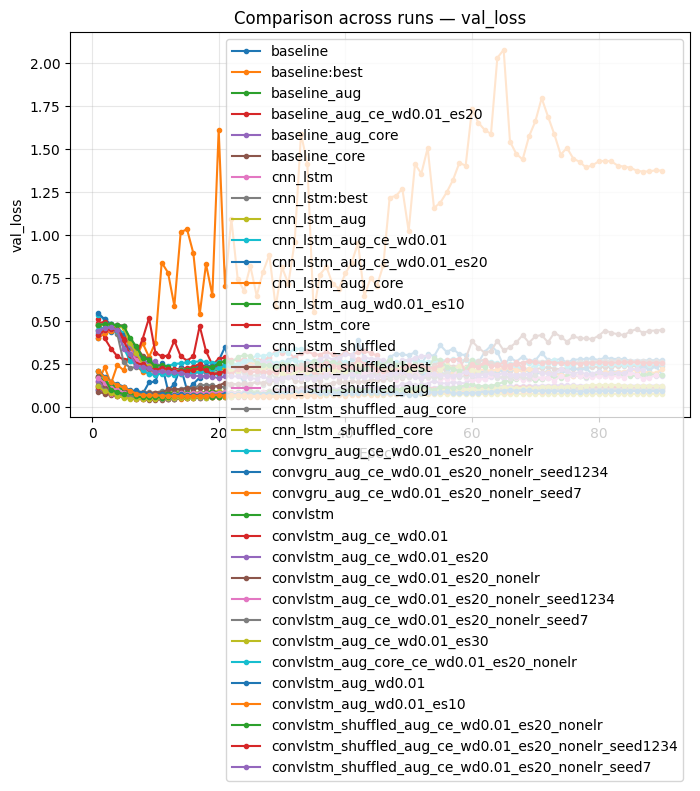

In [9]:
def plot_comparison(metric="val_f1"):
    plt.figure(figsize=(8, 5))
    for name, h in histories.items():
        epochs = [e["epoch"] for e in h]
        values = [e[metric] for e in h]
        plt.plot(epochs, values, label=name, marker='o', markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Comparison across runs — {metric}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_comparison("val_f1")
plot_comparison("val_auroc")
plot_comparison("val_loss")

## Final metrics table — best epoch per run

In [10]:
import pandas as pd

rows = []
for name, h in histories.items():
    best = max(h, key=lambda e: e["val_f1"])
    rows.append({
        "run": name,
        "best_epoch": best["epoch"],
        "f1": round(best["val_f1"], 2),
        "precision": round(best["val_precision"], 2),
        "recall": round(best["val_recall"], 2),
        "auroc": round(best["val_auroc"], 2),
        "epochs_completed": len(h),
    })

df = pd.DataFrame(rows)
df

,run,best_epoch,f1,precision,recall,auroc,epochs_completed
0,baseline,83,44.44,72.73,32.00,66.61,90
1,baseline:best,35,32.77,23.93,52.00,64.20,90
2,baseline_aug,72,86.49,87.67,85.33,94.10,90
3,baseline_aug_ce_wd0.01_es20,25,70.77,83.64,61.33,90.07,45
4,baseline_aug_core,45,82.63,75.00,92.00,95.45,90
5,baseline_core,19,86.84,85.71,88.00,93.79,90
6,cnn_lstm,1,0.00,0.00,0.00,55.86,3
7,cnn_lstm:best,12,86.84,85.71,88.00,95.58,90
8,cnn_lstm_aug,59,85.16,82.50,88.00,98.01,90
9,cnn_lstm_aug_ce_wd0.01,47,84.42,82.28,86.67,96.21,90
